# **Day 98: Project 7 - Land-Cover Change Analysis, Drivers and Future Projection**
*Module 13 - Remote Sensing ML and Publication Projects*

Coal mining and urban growth are reshaping the Dhanbad-Jharia region. A change study answers three questions:
1. **How much** changed, from what to what? (transition matrices, gains/losses, rates, with **unbiased change areas**)
2. **Why there?** (drivers of each transition, modelled with ML)
3. **What next?** (a projection, validated by a **hindcast** before anyone trusts the future map)

> **Working title**: *Mining- and urban-driven land-cover change in the Damodar coalfield, 2016-2024, and projections to 2032 with a validated ML-Markov-CA model.*

> Change analysis compares maps from different years: how much changed, from what to what, and why there. A model of these changes can then project possible future land cover, which must first be tested on a past period.
>
> *Example:* Between 2016 and 2024, cropland near the town turned into built-up area. Distance to roads and to existing settlements explains where this happened.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import uniform_filter, distance_transform_edt, maximum_filter, minimum_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import rs_utils as ru
ru.pub_style()
PROJ = Path("project7_change"); PROJ.mkdir(exist_ok=True)
SEED = 42; PIX_HA = 0.04; CL = ru.LC_CLASSES; K = len(CL)
BUILT, MINE, FOREST, SHRUB, CROP, WATER = 3, 4, 1, 5, 2, 0

## **1. Land-Cover History: True and Mapped**
The landscape of Days 86-91 evolves through 2016, 2020 and 2024: the town and the roadside settlements grow, the open-cast mines expand, and forest near roads degrades to shrub. In reality we never see the true maps, only **classified** maps, each with its own errors (about 5%, concentrated along class edges and between vegetation classes). We simulate both, because comparing them is the lesson of Section 3.

2016: map accuracy vs truth 0.952
2020: map accuracy vs truth 0.950
2024: map accuracy vs truth 0.950


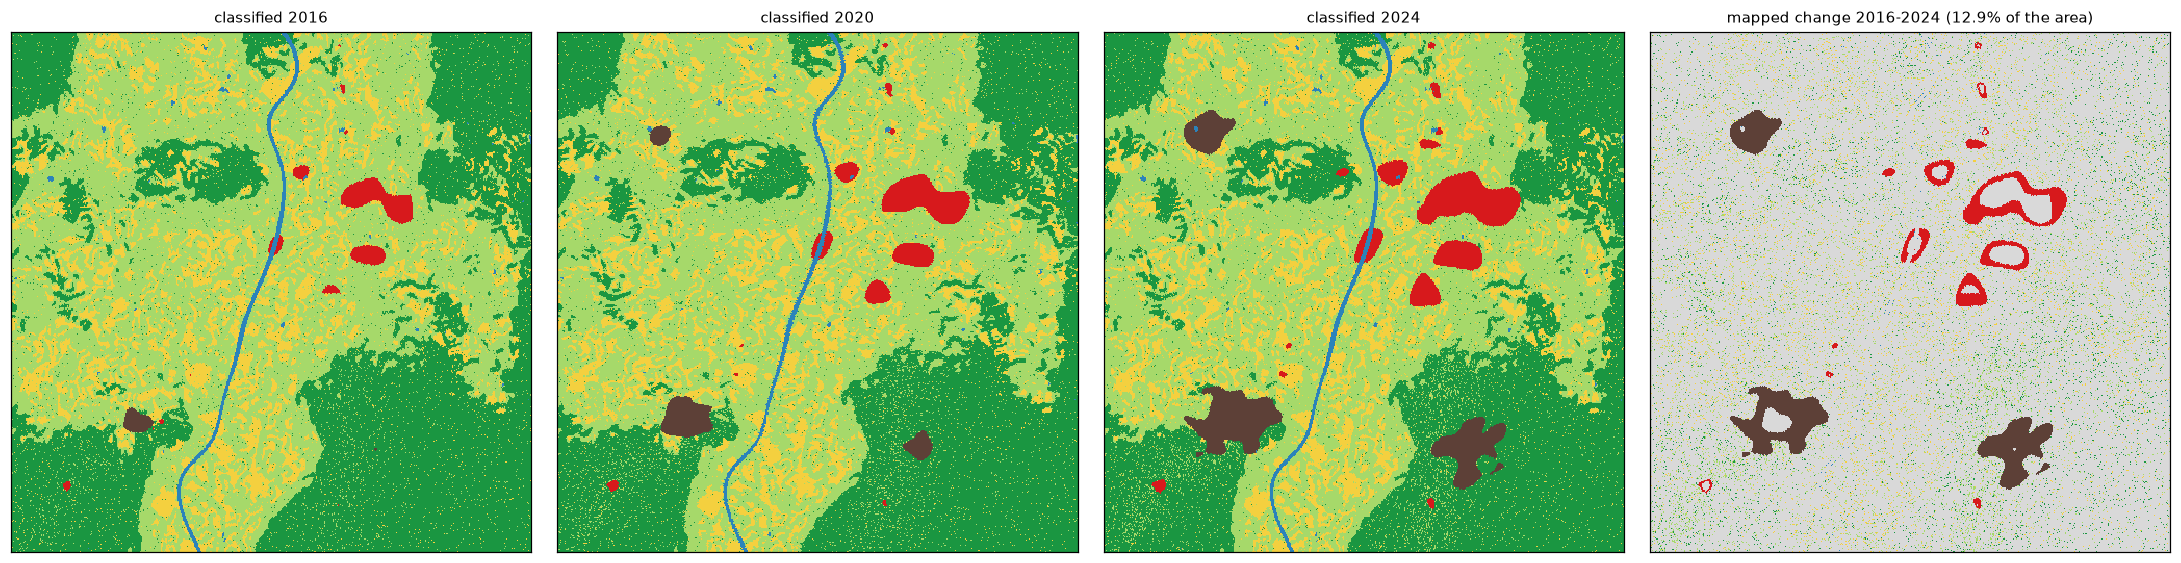

In [2]:
terrain = ru.make_terrain(500, 20.0, 0)
YEARS = {2016: -4, 2020: -2, 2024: 0, 2028: 2}                                   # year -> growth offset of the simulator
u_degrade = np.random.default_rng(7).random((500, 500))                          # fixed draws -> cumulative degradation
def true_map(year):
    lc, dist_road, dist_town = ru.make_landcover(terrain, 20.0, 0, year_offset=YEARS[year])
    p_deg = (year - 2012) / 4 * 0.06 * np.exp(-dist_road / 500)                # forest degradation pressure grows with time
    lc = lc.copy(); lc[(lc == FOREST) & (u_degrade < p_deg)] = SHRUB
    return lc
def classified(lc, seed):
    r = np.random.default_rng(seed); out = lc.copy()
    edge = maximum_filter(lc, 3) != minimum_filter(lc, 3)
    flip = edge & (r.random(lc.shape) < 0.25)                                    # edge pixels take a neighbour's class
    shifted = np.roll(lc, r.choice([-1, 1]), axis=r.integers(2)); out[flip] = shifted[flip]
    conf = (r.random(lc.shape) < 0.04) & np.isin(lc, [FOREST, SHRUB, CROP])      # spectral confusion between vegetation classes
    out[conf] = r.choice([FOREST, SHRUB, CROP], conf.sum())
    return out
truth = {y: true_map(y) for y in [2016, 2020, 2024]}
maps = {y: classified(truth[y], seed=y) for y in truth}
_, dist_road, dist_town = ru.make_landcover(terrain, 20.0, 0, year_offset=0)
for y in maps: print(f"{y}: map accuracy vs truth {np.mean(maps[y] == truth[y]):.3f}")

cmap, norm = ru.categorical_cmap(); T = ru.transform_from_origin(); ext = ru.map_extent(T, (500, 500))
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, y in zip(axes, maps):
    ax.imshow(maps[y], cmap=cmap, norm=norm, extent=ext, interpolation="nearest"); ax.set_title(f"classified {y}"); ax.set_xticks([]); ax.set_yticks([])
chg = maps[2016] != maps[2024]
axes[3].imshow(np.where(chg, maps[2024], np.nan), cmap=cmap, norm=norm, extent=ext, interpolation="nearest"); axes[3].set_facecolor("0.85")
axes[3].set_title(f"mapped change 2016-2024 ({chg.mean():.1%} of the area)"); axes[3].set_xticks([]); axes[3].set_yticks([])
plt.tight_layout(); fig.savefig(PROJ / "fig1_maps.png", dpi=300, bbox_inches="tight"); plt.show()

## **2. Transition Matrix, Gains, Losses and Swap (Table 1)**
The transition (cross-tabulation) matrix gives the area that moved from class i (2016, rows) to class j (2024, columns). From it (Pontius et al. 2004):
- **gain** = column total - diagonal; **loss** = row total - diagonal
- **net change** = |gain - loss|; **swap** = 2 min(gain, loss), i.e. change of location without a change of quantity
- **annual rate of change** (Puyravaud 2003): r = ln(A2 / A1) / (t2 - t1)

In [3]:
def transition_matrix(a, b):
    return pd.crosstab(pd.Categorical(a.ravel(), range(K)), pd.Categorical(b.ravel(), range(K)), dropna=False).values * PIX_HA
tm = transition_matrix(maps[2016], maps[2024])
table1 = pd.DataFrame(tm, index=[f"2016 {c}" for c in CL], columns=[f"2024 {c}" for c in CL]).round(1)
gl = pd.DataFrame({"area 2016 (ha)": tm.sum(1), "area 2024 (ha)": tm.sum(0), "gain": tm.sum(0) - np.diag(tm), "loss": tm.sum(1) - np.diag(tm)}, index=CL)
gl["net change"] = gl["area 2024 (ha)"] - gl["area 2016 (ha)"]; gl["swap"] = 2 * np.minimum(gl.gain, gl.loss)
gl["annual rate %/yr"] = 100 * np.log(gl["area 2024 (ha)"] / gl["area 2016 (ha)"]) / 8
table1.to_csv(PROJ / "table1_transition_matrix_ha.csv"); gl.round(2).to_csv(PROJ / "table1b_gains_losses.csv")
display(table1); gl.round(2)

,2024 water,2024 forest,2024 cropland,2024 built_up,2024 mining_bare,2024 shrub_grass
2016 water,87.0,0.4,1.4,0.2,0.1,1.7
2016 forest,0.4,3108.6,76.1,9.9,139.3,202.6
2016 cropland,1.4,70.0,1341.5,35.4,48.7,174.0
2016 built_up,0.1,0.0,0.0,101.8,0.9,0.0
2016 mining_bare,0.0,0.0,0.0,0.0,19.7,0.0
2016 shrub_grass,2.6,139.7,177.4,122.6,88.2,4048.4


,area 2016 (ha),area 2024 (ha),gain,loss,net change,swap,annual rate %/yr
water,90.80,91.60,4.56,3.76,0.80,7.52,0.11
forest,3536.80,3318.60,210.04,428.24,-218.20,420.08,-0.80
cropland,1670.96,1596.44,254.96,329.48,-74.52,509.92,-0.57
built_up,102.76,269.84,168.08,1.00,167.08,2.00,12.07
mining_bare,19.72,296.80,277.08,0.00,277.08,0.00,33.89
shrub_grass,4578.96,4426.72,378.28,530.52,-152.24,756.56,-0.42


## **3. Spurious Change: Map Errors Compound**
With post-classification comparison, a pixel that is wrong on **either** date shows up as "change". Two maps that are each about 95% accurate can therefore report far more change than really happened. Compare the mapped change with the true change (possible only in simulation):

In [4]:
true_chg = truth[2016] != truth[2024]
print(f"true change: {true_chg.mean():.2%} of the area | mapped change: {chg.mean():.2%} | "
      f"share of mapped change that is real: {np.mean(true_chg[chg]):.1%}")
for name, (a, b) in {"-> built-up": (BUILT, None), "-> mining": (MINE, None), "forest -> shrub": (FOREST, SHRUB)}.items():
    tgt = a if b is None else b
    m_ = (maps[2016] != tgt) & (maps[2024] == tgt) if b is None else (maps[2016] == a) & (maps[2024] == b)
    t_ = (truth[2016] != tgt) & (truth[2024] == tgt) if b is None else (truth[2016] == a) & (truth[2024] == b)
    print(f"  {name:<16}: mapped {m_.sum() * PIX_HA:7.1f} ha | true {t_.sum() * PIX_HA:7.1f} ha")

true change: 5.10% of the area | mapped change: 12.93% | share of mapped change that is real: 37.5%
  -> built-up     : mapped   168.1 ha | true   167.8 ha
  -> mining       : mapped   277.1 ha | true   276.7 ha
  forest -> shrub : mapped   202.6 ha | true    65.2 ha


The remedy is the same as in Day 91, applied to **change strata**. Define strata from the mapped change ("stable", "-> built-up", "-> mining", "forest loss", "other change"), draw a stratified random sample, have interpreters label the **true** change at each point by viewing both dates together, and estimate the change areas with confidence intervals (Olofsson et al. 2014).

In [5]:
def change_class(a, b):
    c = np.zeros(a.shape, int)                                                   # 0 stable
    c[(a != b) & (b == BUILT)] = 1; c[(a != b) & (b == MINE)] = 2
    c[(a == FOREST) & (b == SHRUB)] = 3; c[(a != b) & (c == 0)] = 4
    return c
CH = ["stable", "to built-up", "to mining", "forest to shrub", "other change"]
mapped_ch, true_ch = change_class(maps[2016], maps[2024]), change_class(truth[2016], truth[2024])
counts = {k: int((mapped_ch == k).sum()) for k in range(5)}
alloc = {0: 300, 1: 100, 2: 100, 3: 100, 4: 100}
r, c, s = ru.stratified_random_sample(mapped_ch, alloc, seed=SEED)
summ, _ = ru.olofsson_accuracy(s, true_ch[r, c], counts, PIX_HA, CH)
summ["TRUE area (ha)"] = [np.sum(true_ch == k) * PIX_HA for k in range(5)]
summ.round(2).to_csv(PROJ / "table2_change_area_estimates.csv")
summ[["class", "mapped_area_ha", "adjusted_area_ha", "area_95CI_ha", "TRUE area (ha)", "UA", "PA"]].round(2)

,class,mapped_area_ha,adjusted_area_ha,area_95CI_ha,TRUE area (ha),UA,PA
0,stable,8707.00,9519.02,17.50,9490.40,1.00,0.91
1,to built-up,168.08,161.36,6.49,167.76,0.96,1.00
2,to mining,277.08,277.08,0.00,276.68,1.00,1.00
3,forest to shrub,202.60,42.55,16.26,65.16,0.21,1.00
4,other change,645.24,0.00,0.00,0.00,0.00,NaN


The stratified estimator removes most of the spurious change. Change classes driven by real processes (to built-up, to mining) have high user's accuracy. The classes fed mainly by classification noise (forest to shrub, "other change") have very low user's accuracy, and their adjusted areas shrink toward the truth. This is why high-impact change studies (e.g. Hansen et al. 2013 and their sample-based follow-ups) report sample-based change areas.

## **4. Why There? Transition-Potential Models**
For each major transition we model where it happens, from spatial drivers measured at the **start** of the period:
- distance to roads, distance to the town centre, distance to existing built-up or mining, the neighbourhood share of built-up or mining (5 x 5 and 15 x 15), slope, elevation

Calibrate on **2016 -> 2020**, then test on **2020 -> 2024** (temporal validation). Real drivers would add population, policy zones, coal-lease boundaries and so on.

In [6]:
def drivers(lc):
    d = {"dist_road_m": dist_road, "dist_town_m": dist_town, "slope_deg": terrain["slope"], "elevation_m": terrain["dem"],
         "dist_built_m": distance_transform_edt(lc != BUILT) * 20, "dist_mine_m": distance_transform_edt(lc != MINE) * 20,
         "built_share_5": uniform_filter((lc == BUILT).astype(float), 5), "built_share_15": uniform_filter((lc == BUILT).astype(float), 15),
         "mine_share_5": uniform_filter((lc == MINE).astype(float), 5), "forest_share_15": uniform_filter((lc == FOREST).astype(float), 15)}
    return np.stack([np.asarray(v, np.float32).ravel() for v in d.values()], 1), list(d.keys())

TRANS = {"to built-up": (lambda a: np.isin(a, [CROP, SHRUB, FOREST]), BUILT), "to mining": (lambda a: np.isin(a, [CROP, SHRUB, FOREST]), MINE),
         "forest to shrub": (lambda a: a == FOREST, SHRUB)}
rng = np.random.default_rng(SEED)
def transition_data(a, b, from_fn, to):
    Xd, names = drivers(a); cand = np.flatnonzero(from_fn(a).ravel())
    yv = (b.ravel()[cand] == to).astype(int)
    pos, neg = cand[yv == 1], cand[yv == 0]
    neg = rng.choice(neg, min(len(neg), 5 * max(len(pos), 50)), replace=False)
    idx = np.concatenate([pos, neg]); return Xd[idx], (b.ravel()[idx] == to).astype(int), names

tp_models, rows = {}, []
for tname, (from_fn, to) in TRANS.items():
    Xc, yc, names = transition_data(maps[2016], maps[2020], from_fn, to)
    m = RandomForestClassifier(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Xc, yc); tp_models[tname] = m
    Xv, _ = drivers(maps[2020]); cand = np.flatnonzero(from_fn(maps[2020]).ravel())
    yv = (maps[2024].ravel()[cand] == to).astype(int)
    auc = roc_auc_score(yv, m.predict_proba(Xv[cand])[:, 1]) if 0 < yv.sum() < len(yv) else np.nan
    imp = pd.Series(m.feature_importances_, index=names).sort_values(ascending=False)
    rows.append({"transition": tname, "calibration events (2016-20)": int(yc.sum()), "validation AUC (2020-24)": auc, "top drivers": ", ".join(imp.index[:3])})
table3 = pd.DataFrame(rows).set_index("transition"); table3.to_csv(PROJ / "table3_transition_models.csv"); table3.round(3)

,calibration events (2016-20),validation AUC (2020-24),top drivers
transition,,,
to built-up,1873,0.955,"dist_built_m, built_share_15, dist_town_m"
to mining,1805,0.982,"dist_mine_m, dist_town_m, dist_road_m"
forest to shrub,4746,0.782,"forest_share_15, elevation_m, slope_deg"


## **5. Projection: Markov Quantities and CA Allocation**
**How much** changes comes from a Markov chain: the transition probabilities P_ij estimated from 2016 -> 2020 are applied to the 2020 class areas to get the expected amount of each transition by 2024. **Where** it happens comes from the transition-potential maps, boosted by a **neighbourhood (cellular-automata) effect**: pixels next to existing built-up or mining are more likely to convert. We allocate in several iterations so that new built-up pixels raise their neighbours' potential.

In [7]:
P = transition_matrix(maps[2016], maps[2020]); P = P / P.sum(1, keepdims=True)
FROM = {"to built-up": [CROP, SHRUB, FOREST], "to mining": [CROP, SHRUB, FOREST], "forest to shrub": [FOREST]}

def project(start, steps=1, n_iter=2, noise=0.0, seed=0, ca=2.0):
    """One step = one 4-year period. Markov demand per transition, then iterative allocation by potential x neighbourhood."""
    r = np.random.default_rng(seed); cur = start.copy()
    for _ in range(steps):
        counts_now = np.bincount(cur.ravel(), minlength=K)
        demand = {t: int(round(sum(counts_now[i] * P[i, to] for i in FROM[t]))) for t, (_, to) in TRANS.items()}
        new = cur.copy()
        for _ in range(n_iter):
            Xd, _ = drivers(new)                                                 # drivers updated after each allocation round
            for t, (from_fn, to) in TRANS.items():
                pot = tp_models[t].predict_proba(Xd)[:, 1].reshape(cur.shape)
                if to in (BUILT, MINE): pot = pot * (1 + ca * uniform_filter((new == to).astype(float), 3))   # CA neighbourhood effect
                if noise: pot = pot * np.exp(noise * r.normal(size=pot.shape))
                pot[~from_fn(new)] = -1
                idx = np.argsort(-pot.ravel())[:demand[t] // n_iter]; new.ravel()[idx] = to
        cur = new
    return cur

def figure_of_merit(start, ref_end, sim_end):
    oc, sc = start != ref_end, start != sim_end
    hits = np.sum(oc & sc & (sim_end == ref_end)); wrong = np.sum(oc & sc & (sim_end != ref_end))
    misses = np.sum(oc & ~sc); fa = np.sum(~oc & sc)
    return {"FoM": hits / (hits + wrong + misses + fa), "hits": hits, "misses": misses, "false alarms": fa, "wrong hits": wrong}

sim2024 = project(maps[2020])
fom_obs = figure_of_merit(maps[2020], maps[2024], sim2024)
fom_true = figure_of_merit(truth[2020], truth[2024], project(truth[2020]))
print(f"hindcast 2020 -> 2024: Figure of Merit {fom_obs['FoM']:.3f} against the classified 2024 map")
print(f"  agreement with 2024 map: model {np.mean(sim2024 == maps[2024]):.4f} vs persistence (no change) {np.mean(maps[2020] == maps[2024]):.4f}")
print(f"  (simulation only) FoM when calibrated and validated on TRUE maps: {fom_true['FoM']:.3f}")
pd.DataFrame([fom_obs, fom_true], index=["classified maps", "true maps (simulation only)"]).round(3)

hindcast 2020 -> 2024: Figure of Merit 0.135 against the classified 2024 map
  agreement with 2024 map: model 0.8845 vs persistence (no change) 0.8789
  (simulation only) FoM when calibrated and validated on TRUE maps: 0.209


,FoM,hits,misses,false alarms,wrong hits
classified maps,0.135,4504,25134,3116,637
true maps (simulation only),0.209,2804,5152,5256,204


Two lessons that reviewers will check:
- **Overall agreement is dominated by persistence**: a model that predicts "no change" already agrees with almost every pixel. The Figure of Merit (Pontius et al. 2008) scores only the change pixels. Published LUCC models often reach a FoM of only 0.1-0.3, so report it honestly.
- With classified maps, a large part of the observed "change" is classification noise that no model can predict. That caps the FoM. Cleaner maps, or modelling only well-mapped transitions, help more than a fancier model.

## **6. Projection to 2028 and 2032 (Fig. 3)**
After validation, re-calibrate on the most recent period and project forward. Treat projections as **scenarios** under the assumption that past trends continue (business as usual), not as forecasts.

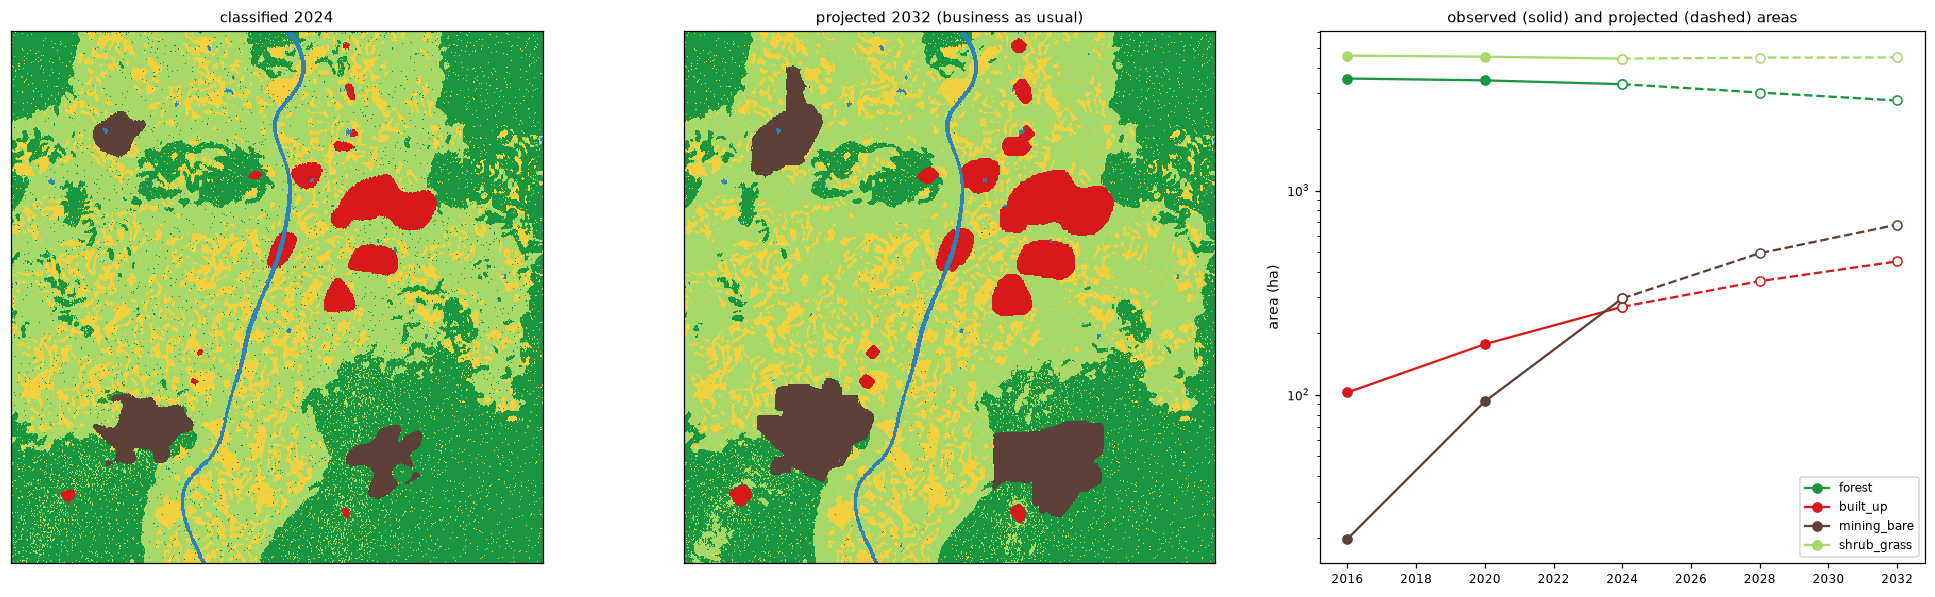

,2016,2020,2024,2028,2032
water,91.0,91.0,92.0,92.0,92.0
forest,3537.0,3465.0,3319.0,3021.0,2763.0
cropland,1671.0,1649.0,1596.0,1557.0,1525.0
built_up,103.0,177.0,270.0,360.0,450.0
mining_bare,20.0,93.0,297.0,494.0,682.0
shrub_grass,4579.0,4526.0,4427.0,4477.0,4489.0


In [8]:
P = transition_matrix(maps[2020], maps[2024]); P = P / P.sum(1, keepdims=True)
for t, (from_fn, to) in TRANS.items():
    Xc, yc, _ = transition_data(maps[2020], maps[2024], from_fn, to)
    tp_models[t] = RandomForestClassifier(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Xc, yc)
proj2028 = project(maps[2024], steps=1); proj2032 = project(proj2028, steps=1)
areas = pd.DataFrame({y: np.bincount(m.ravel(), minlength=K) * PIX_HA for y, m in [(2016, maps[2016]), (2020, maps[2020]), (2024, maps[2024]), (2028, proj2028), (2032, proj2032)]}, index=CL)
areas.round(0).to_csv(PROJ / "table4_areas_projection.csv")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (t, m) in zip(axes[:2], [("classified 2024", maps[2024]), ("projected 2032 (business as usual)", proj2032)]):
    ax.imshow(m, cmap=cmap, norm=norm, extent=ext, interpolation="nearest"); ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
for k in [FOREST, BUILT, MINE, SHRUB]:
    axes[2].plot(areas.columns[:3], areas.loc[CL[k]].values[:3], "-o", color=ru.LC_COLORS[k], label=CL[k])
    axes[2].plot(areas.columns[2:], areas.loc[CL[k]].values[2:], "--o", color=ru.LC_COLORS[k], mfc="w")
axes[2].set_yscale("log"); axes[2].set_ylabel("area (ha)"); axes[2].legend(); axes[2].set_title("observed (solid) and projected (dashed) areas")
plt.tight_layout(); fig.savefig(PROJ / "fig3_projection.png", dpi=300, bbox_inches="tight"); plt.show()
areas.round(0)

# **Part 2: Going Deeper**

## **7. Uncertainty of the Projection**
A single projected map hides how arbitrary the exact allocation is. Run the allocation 10 times with random perturbations of the potentials, and map the **probability that each pixel becomes built-up by 2028**. Stakeholders read such probability maps more reliably than a single crisp map.

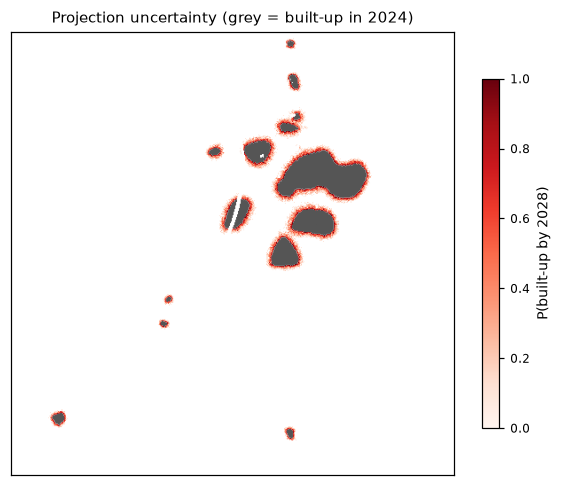

pixels converted in all 10 runs: 176 | in some runs: 5373


In [9]:
runs = np.stack([project(maps[2024], steps=1, noise=0.5, seed=s) == BUILT for s in range(10)])
p_built = runs.mean(0); p_built[maps[2024] == BUILT] = np.nan
fig, ax = plt.subplots(figsize=(6.5, 5.5)); im = ax.imshow(np.where(p_built > 0, p_built, np.nan), cmap="Reds", vmin=0, vmax=1, extent=ext)
ax.imshow(np.where(maps[2024] == BUILT, 1, np.nan), cmap="gray_r", vmin=0, vmax=1.5, extent=ext); fig.colorbar(im, ax=ax, shrink=0.75, label="P(built-up by 2028)")
ax.set_title("Projection uncertainty (grey = built-up in 2024)"); ax.set_xticks([]); ax.set_yticks([]); plt.show()
print(f"pixels converted in all 10 runs: {np.sum(p_built == 1)} | in some runs: {np.sum((p_built > 0) & (p_built < 1))}")

## **Practice Problems**
1. Compute the annual rate of change for built-up and mining for 2016-2020 and 2020-2024 separately. Is growth accelerating?
2. Remove the CA neighbourhood effect from `project` (multiply by 1 instead). How does the hindcast FoM change?
3. Which drivers matter most for the transition to mining? Plot the RF importances.
4. *(Advanced)* Smooth the classified maps with a 3 x 3 majority filter before computing change. How much spurious change disappears, and how much real change is lost?

In [10]:
# Solution 1
for k in [BUILT, MINE]:
    a16, a20, a24 = [np.sum(maps[y] == k) * PIX_HA for y in (2016, 2020, 2024)]
    print(f"{CL[k]:<12}: {100 * np.log(a20 / a16) / 4:.2f} %/yr (2016-20), {100 * np.log(a24 / a20) / 4:.2f} %/yr (2020-24)")

built_up    : 13.62 %/yr (2016-20), 10.52 %/yr (2020-24)
mining_bare : 38.73 %/yr (2016-20), 29.05 %/yr (2020-24)


In [11]:
# Solution 2
P = transition_matrix(maps[2016], maps[2020]); P = P / P.sum(1, keepdims=True)
for t, (from_fn, to) in TRANS.items():
    Xc, yc, _ = transition_data(maps[2016], maps[2020], from_fn, to)
    tp_models[t] = RandomForestClassifier(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Xc, yc)
fom_noca = figure_of_merit(maps[2020], maps[2024], project(maps[2020], ca=0.0))["FoM"]
print(f"FoM without neighbourhood effect {fom_noca:.3f} vs with {fom_obs['FoM']:.3f}")

FoM without neighbourhood effect 0.120 vs with 0.135


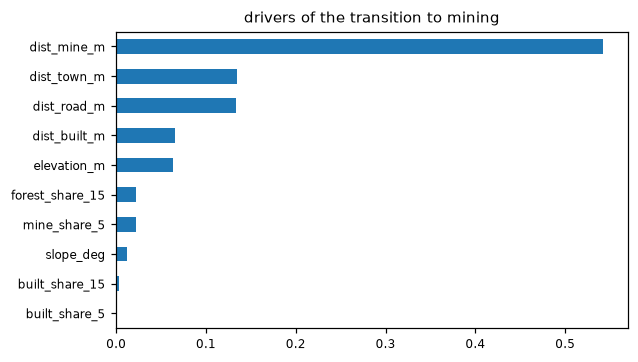

In [12]:
# Solution 3
Xc, yc, names = transition_data(maps[2016], maps[2020], *TRANS["to mining"])
imp = pd.Series(RandomForestClassifier(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Xc, yc).feature_importances_, index=names).sort_values()
imp.plot.barh(figsize=(6, 3.5), title="drivers of the transition to mining"); plt.show()

In [13]:
# Solution 4
def majority(lc, size=3):
    return np.stack([uniform_filter((lc == k).astype(float), size) for k in range(K)]).argmax(0)
m16, m24 = majority(maps[2016]), majority(maps[2024]); chg_f = m16 != m24
print(f"mapped change: raw {chg.mean():.2%} -> filtered {chg_f.mean():.2%} | true change {true_chg.mean():.2%}")
print(f"share of mapped change that is real: raw {np.mean(true_chg[chg]):.1%} -> filtered {np.mean(true_chg[chg_f]):.1%}; "
      f"real change captured: raw {np.mean(chg[true_chg]):.1%} -> filtered {np.mean(chg_f[true_chg]):.1%}")

mapped change: raw 12.93% -> filtered 7.62% | true change 5.10%
share of mapped change that is real: raw 37.5% -> filtered 57.8%; real change captured: raw 95.3% -> filtered 86.4%


## **Key References**
- Pontius, R. G., Shusas, E., & McEachern, M. (2004). Detecting important categorical land changes while accounting for persistence. *Agriculture, Ecosystems & Environment*, 101(2-3), 251-268.
- Pontius, R. G. et al. (2008). Comparing the input, output, and validation maps for several models of land change. *The Annals of Regional Science*, 42(1), 11-37.
- Puyravaud, J.-P. (2003). Standardizing the calculation of the annual rate of deforestation. *Forest Ecology and Management*, 177(1-3), 593-596.
- Olofsson, P. et al. (2014). Good practices for estimating area and assessing accuracy of land change. *Remote Sensing of Environment*, 148, 42-57.
- Liu, X. et al. (2017). A future land use simulation model (FLUS) for simulating multiple land use scenarios by coupling human and natural effects. *Landscape and Urban Planning*, 168, 94-116.
- Eastman, J. R., & Toledano, J. (2018). A short presentation of the Land Change Modeler (LCM). In *Geomatic Approaches for Modeling Land Change Scenarios*, Springer, 499-505.
- Hansen, M. C. et al. (2013). High-resolution global maps of 21st-century forest cover change. *Science*, 342(6160), 850-853.
- Verburg, P. H., Schot, P. P., Dijst, M. J., & Veldkamp, A. (2004). Land use change modelling: current practice and research priorities. *GeoJournal*, 61(4), 309-324.